In [1]:
from obspy.imaging.cm import viridis_white

In [2]:
import numpy as np
import pandas as pd
import os, sys, glob
%load_ext autoreload
%autoreload 2
import RM_utils as utils
import nibabel as nib
from config import *
from nibabel import Nifti1Image
from scipy import stats
from scipy.stats import ttest_rel,ttest_ind
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import matplotlib.pyplot as plt
import scprep, tphate, phate
from nilearn import plotting
import shutil
import seaborn as sns
from brainiak.searchlight.searchlight import Searchlight
from camcan_utils import get_brain_cmap
import skdim
import camcan_utils as cccutils
import narratives_utils as narutils
import statsmodels.api as sm
import ide_helpers as ide
import task_comparison as tc
from nilearn.glm import threshold_stats_img, fdr_threshold
from nilearn.image import threshold_img, math_img
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib as mpl
# from statsmodels.stats.multitest import fdrcorrection
# from statsmodels.stats.weightstats import ttest_ind
#statsmodels.stats.weightstats.ttest_ind(x1, x2, alternative='two-sided', usevar='pooled', weights=(None, None), value=0)

/gpfs/milgram/project/casey/elb77/conda_envs/env_tda/lib/python3.7/site-packages/nilearn/__init__.py:69: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


# Figuring out colormaps

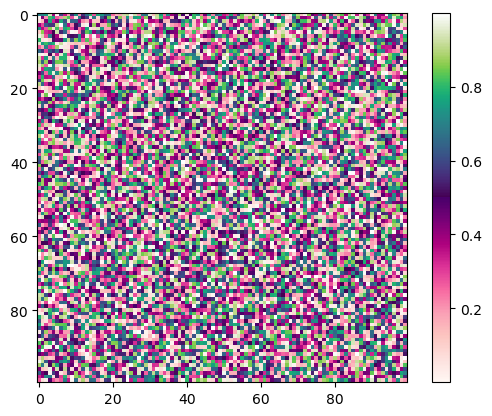

In [3]:
first = viridis_white
second = plt.cm.RdPu
colors1 = first(np.linspace(0., 1, 128))
colors2 = second(np.linspace(0, 1, 128))
colors_combined = np.vstack((colors2,colors1))
cmap_combined = ListedColormap(colors_combined, name='ViridisWhiteRdPu')
viridis_rdpu_cmap = ListedColormap(colors_combined, name='ViridisWhiteRdPu')

plt.imshow(np.random.random((100, 100)), cmap=cmap_combined)
plt.colorbar()
plt.show()

In [4]:
custom_cmap = ['#F7E8D4','#CE9E8E','#AE766E','#8E4D4D','#5C0A33','#460A5D','#3B528B','#21918C','#4EC36B','#FBE723','#FDFBE0']

In [5]:
custom_cmap_lc= ListedColormap(custom_cmap)

In [6]:
plot_colorbar(10, np.arange(10), cmap=custom_cmap_lc)

NameError: name 'plot_colorbar' is not defined

In [ ]:
sns.palplot(sns.color_palette(custom_cmap, 20, as_cmap=True))

In [ ]:
viridis_hex = ['#460A5D','#3B528B',
               '#21918C','#4EC36B','#DDE318','#FBE723','#FAF075','#FDFBE0']
sns.palplot(viridis_hex)

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib import ticker

def plot_colorbar(vmax, values, direction='horizontal', cmap='RdBu_r', nbins=5, out_fn=None):
	
	fig = plt.figure()
	
	divnorm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
	psm = plt.pcolormesh([-values, values], norm=divnorm, cmap=cmap)
	plt.clf()
	
	# xloc, yloc, size x, size y
	if direction == 'horizontal':
		cbar_ax = fig.add_axes([0.5, 0, 0.6, 0.05])
	elif direction == 'vertical':
		cbar_ax = fig.add_axes([0.5, 0, 0.05, 0.6])
	
	fig.colorbar(psm, cax=cbar_ax, orientation=direction, ticks=ticker.MaxNLocator(nbins=nbins))
	
	if out_fn:
		plt.savefig(out_fn, bbox_inches='tight', transparent=True)

In [ ]:
plot_colorbar(16, np.arange(-16, 16), cmap=viridis_rdpu_cmap, direction='horizontal',out_fn='ccn_plots/viridis_rdpu_cmap.pdf')

In [ ]:
plot_colorbar(16, np.arange(-16, 16), cmap=viridis_rdpu_cmap, direction='vertical',out_fn='ccn_plots/viridis_rdpu_cmap_v.pdf')

In [ ]:
plot_colorbar(0.45, np.arange(0.45), cmap=viridis_white, out_fn='ccn_plots/brain_cmap_isc_r.pdf')

# loading data

In [8]:
rm_mask = utils.get_intersect_mask()
nar_mask = narutils.get_intersect_mask()

narr_subjects = narutils.get_intersecting_subjects()
rm_subjects = utils.get_intersecting_subjects()

cmap = utils.get_brain_cmap()


rest_mickey = np.load('RestMovie/results/all_subject_arrays/REST_MICKEY_tphate_optt_knn20_smooth_window1_difference_per_subject.npy')
rest_aero = np.load('RestMovie/results/all_subject_arrays/REST_AERONAUT_tphate_optt_knn20_smooth_window1_difference_per_subject.npy')
aero_mickey = np.load('RestMovie/results/all_subject_arrays/AERONAUT_MICKEY_tphate_optt_knn20_smooth_window1_difference_per_subject.npy')

all_mickey = np.load('RestMovie/results/all_subject_arrays/mickey_tphate_optt_knn20_smooth_window1_all_subject_results.npy')
all_aero = np.load('RestMovie/results/all_subject_arrays/aeronaut_tphate_optt_knn20_smooth_window1_all_subject_results.npy')
all_rest = np.load('RestMovie/results/all_subject_arrays/rest_tphate_optt_knn20_smooth_window1_all_subject_results.npy')

all_mickey_pca = np.load('RestMovie/results/all_subject_arrays/mickey__PCA_all_subject_results.npy')
all_aero_pca = np.load('RestMovie/results/all_subject_arrays/aeronaut__PCA_all_subject_results.npy')
all_rest_pca = np.load('RestMovie/results/all_subject_arrays/rest__PCA_all_subject_results.npy')

all_mickey_lpca = np.load('RestMovie/results/all_subject_arrays/mickey_lPCA_all_subject_results.npy')
all_aero_lpca = np.load('RestMovie/results/all_subject_arrays/aeronaut_lPCA_all_subject_results.npy')
all_rest_lpca = np.load('RestMovie/results/all_subject_arrays/rest_lPCA_all_subject_results.npy')

all_mickey_mle = np.load('RestMovie/results/all_subject_arrays/mickey_MLE_all_subject_results.npy')
all_aero_mle = np.load('RestMovie/results/all_subject_arrays/aeronaut_MLE_all_subject_results.npy')
all_rest_mle = np.load('RestMovie/results/all_subject_arrays/rest_MLE_all_subject_results.npy')

all_aero_ph = np.load('RestMovie/results/all_subject_arrays/aeronaut_PHATE_SE_delta_optt_all_subject_results.npy')
all_mickey_ph = np.load('RestMovie/results/all_subject_arrays/mickey_PHATE_SE_delta_optt_all_subject_results.npy')
all_rest_ph = np.load('RestMovie/results/all_subject_arrays/rest_PHATE_SE_delta_optt_all_subject_results.npy')

all_mickey_fs = np.load('RestMovie/results/all_subject_arrays/mickey_FisherS_all_subject_results.npy')
all_aero_fs = np.load('RestMovie/results/all_subject_arrays/aeronaut_FisherS_all_subject_results.npy')
all_rest_fs = np.load('RestMovie/results/all_subject_arrays/rest_FisherS_all_subject_results.npy')

all_mickey_t = np.load('RestMovie/results/all_subject_arrays/mickey_TPHATE_SE_delta_optt_all_subject_results.npy')
all_aero_t = np.load('RestMovie/results/all_subject_arrays/aeronaut_TPHATE_SE_delta_optt_all_subject_results.npy')
all_rest_t = np.load('RestMovie/results/all_subject_arrays/rest_tphate_optt_knn50_smooth_window4_all_subject_results.npy')


RM_RES = {'DIFFERENCE_OPTT':{'Rest-Mickey':rest_mickey, 'Rest-Aeronaut':rest_aero, 'Aeronaut-Mickey':aero_mickey},
         'OPTT':{'Mickey':all_mickey, 'Aeronaut':all_aero, 'Rest':all_rest},
          'PCA':{'Mickey':all_mickey_pca, 'Aeronaut':all_aero_pca, 'Rest':all_rest_pca},
          'PHATE_T':{'Mickey':all_mickey_ph, 'Aeronaut':all_aero_ph, 'Rest':all_rest_ph},
          'FISHERS':{'Mickey':all_mickey_fs, 'Aeronaut':all_aero_fs, 'Rest':all_rest_fs},
          'lPCA':{'Mickey':all_mickey_lpca, 'Aeronaut':all_aero_lpca, 'Rest':all_rest_lpca},
          'TPHATE': {'Mickey':all_mickey_t , 'Aeronaut': all_aero_t, 'Rest': all_rest_t},
          'MLE': {'Mickey':all_mickey_mle , 'Aeronaut': all_aero_mle, 'Rest': all_rest_mle}
         }

In [33]:
all_black = np.load('Narratives/results/all_subject_arrays/black_optt_all_subject_results.npy')
all_bronx = np.load('Narratives/results/all_subject_arrays/bronx_optt_all_subject_results.npy')
all_pieman = np.load('Narratives/results/all_subject_arrays/piemanpni_optt_all_subject_results.npy')
all_forgot = np.load('Narratives/results/all_subject_arrays/forgot_optt_all_subject_results.npy')

all_black_pca = np.load('Narratives/results/all_subject_arrays/black__PCA_all_subject_results.npy')
all_bronx_pca = np.load('Narratives/results/all_subject_arrays/bronx__PCA_all_subject_results.npy')
all_pieman_pca = np.load('Narratives/results/all_subject_arrays/piemanpni__PCA_all_subject_results.npy')
all_forgot_pca = np.load('Narratives/results/all_subject_arrays/forgot__PCA_all_subject_results.npy')

all_black_lpca = np.load('Narratives/results/all_subject_arrays/black_lPCA_all_subject_results.npy')
all_bronx_lpca = np.load('Narratives/results/all_subject_arrays/bronx_lPCA_all_subject_results.npy')
all_pieman_lpca = np.load('Narratives/results/all_subject_arrays/piemanpni_lPCA_all_subject_results.npy')
all_forgot_lpca = np.load('Narratives/results/all_subject_arrays/forgot_lPCA_all_subject_results.npy')

all_black_fs = np.load('Narratives/results/all_subject_arrays/black_FisherS_all_subject_results.npy')
all_bronx_fs = np.load('Narratives/results/all_subject_arrays/bronx_FisherS_all_subject_results.npy')
all_pieman_fs = np.load('Narratives/results/all_subject_arrays/piemanpni_FisherS_all_subject_results.npy')
all_forgot_fs = np.load('Narratives/results/all_subject_arrays/forgot_FisherS_all_subject_results.npy')

all_black_mle = np.load('Narratives/results/all_subject_arrays/black_MLE_all_subject_results.npy')
all_bronx_mle = np.load('Narratives/results/all_subject_arrays/bronx_MLE_all_subject_results.npy')
all_pieman_mle = np.load('Narratives/results/all_subject_arrays/piemanpni_MLE_all_subject_results.npy')
all_forgot_mle = np.load('Narratives/results/all_subject_arrays/forgot_MLE_all_subject_results.npy')

all_black_ph = np.load('Narratives/results/all_subject_arrays/black_PHATE_SE_delta_optt_all_subject_results.npy')
all_bronx_ph = np.load('Narratives/results/all_subject_arrays/bronx_PHATE_SE_delta_optt_all_subject_results.npy')
all_pieman_ph = np.load('Narratives/results/all_subject_arrays/piemanpni_PHATE_SE_delta_optt_all_subject_results.npy')
all_forgot_ph = np.load('Narratives/results/all_subject_arrays/forgot_PHATE_SE_delta_optt_all_subject_results.npy')

NAR_RES = {
         'OPTT':{'Black':all_black, 'Bronx':all_bronx, 'Forgot':all_forgot, 'Pieman':all_pieman},
          'PCA':{'Black':all_black_pca, 'Bronx':all_bronx_pca, 'Forgot':all_forgot_pca, 'Pieman':all_pieman_pca},
          'lPCA':{'Black':all_black_lpca, 'Bronx':all_bronx_lpca, 'Forgot':all_forgot_lpca, 'Pieman':all_pieman_lpca},
          'FISHERS':{'Black':all_black_fs, 'Bronx':all_bronx_fs, 'Forgot':all_forgot_fs, 'Pieman':all_pieman_fs},
    'PHATE':{'Black':all_black_ph, 'Bronx':all_bronx_ph, 'Forgot':all_forgot_ph, 'Pieman':all_pieman_ph
            },
    'MLE':{'Black':all_black_mle, 'Bronx':all_bronx_mle, 'Forgot':all_forgot_mle, 'Pieman':all_pieman_mle
            }
         }

In [34]:
# create dataframe with average results 
# fig,ax=plt.subplots(1, 4, figsize=, dpi=100)
N = len(narutils.get_intersecting_subjects())
i = -1
df = pd.DataFrame(columns=['subject','average_dim','metric','task'])

for meth,dic in NAR_RES.items():
    i+=1
    for k,v in dic.items():
        vm = np.mean(v,axis=1)
        temp = pd.DataFrame({'subject':np.arange(len(vm)), 'average_dim':vm,
                             'metric':np.repeat(meth, len(vm)),'task':np.repeat(k, len(vm))})
        df = pd.concat([df, temp])
df.to_csv('Narratives/results/searchlight_avg_dimensionality.csv')

In [11]:
# create dataframe with average results 
# fig,ax=plt.subplots(1, 4, figsize=, dpi=100)
N = len(utils.get_intersecting_subjects())
i = -1
df = pd.DataFrame(columns=['subject','average_dim','metric','task'])

for meth,dic in RM_RES.items():
    i+=1
    for k,v in dic.items():
        vm = np.mean(v,axis=1)
        temp = pd.DataFrame({'subject':np.arange(len(vm)), 'average_dim':vm,
                             'metric':np.repeat(meth, len(vm)),'task':np.repeat(k, len(vm))})
        df = pd.concat([df, temp])
df.to_csv('RestMovie/results/searchlight_avg_dimensionality.csv')

# whole brain ide

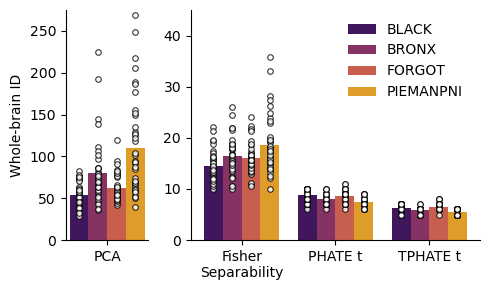

In [492]:
wb_ide_nar = pd.read_csv('Narratives/results/whole_brain_ide.csv')

N = len(utils.get_intersecting_subjects())
task_order = ["BLACK",'BRONX','FORGOT','PIEMANPNI']
metric_order = ['lPCA','FisherS','PHATE_optt', 'TPHATE_optt']
met_names = ['PCA','Fisher\nSeparability', 'PHATE t', 'TPHATE t']

fig,ax=plt.subplots(1,2,gridspec_kw={'width_ratios': [1, 3.5]},figsize=(5,3))

# plot pca on one set of axes
g = sns.barplot(x='metric', y='ide', ci=None, hue='task', data=wb_ide_nar, 
                order=metric_order[:1], hue_order=task_order, palette='inferno',ax=ax[0])
# plt.xticks(rotation=90)
g.set(xlabel='',  ylabel='Whole-brain ID', xticklabels=[met_names[0]], ylim=[0,275])#, yticklabels=np.arange(0,360,60))
ax[0].get_legend().set_visible(False)

for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[0] 
        points = wb_ide_nar[(wb_ide_nar['metric']==meth) & (wb_ide_nar['task']==task)]['ide'].values

        ax[0].scatter(x=np.repeat(x+w, len(points)),  y=points, edgecolors='k', alpha=0.8,
                   zorder=10, linewidths=0.8, s=16, c="white")


# plot others on one set of axes
g = sns.barplot(x='metric', y='ide', ci=None, hue='task', data=wb_ide_nar, 
                order=metric_order[1:], hue_order=task_order, palette='inferno',ax=ax[1])
g.set(xlabel='',  ylabel='', xticklabels=met_names[1:], ylim=[0,45], yticks=np.arange(0,45,10))


for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[c+1] 
        points = wb_ide_nar[(wb_ide_nar['metric']==meth) & (wb_ide_nar['task']==task)]['ide'].values

        ax[1].scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=0.8,
                   zorder=10, linewidths=0.8, s=16, c="white")
        
sns.move_legend(
    ax[1], "upper left",
    bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False,
)
sns.despine()
fig.tight_layout()
plt.savefig('ccn_plots/barplot_whole_brain_narratives.pdf', bbox_inches = "tight",transparent=True, format='pdf')


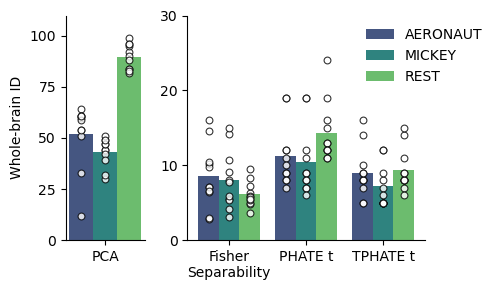

In [586]:
wb_ide_rm = pd.read_csv('RestMovie/results/whole_brain_ide.csv')

N = len(utils.get_intersecting_subjects())
task_order = ['AERONAUT','MICKEY','REST']
metric_order = ['PCA','FisherS','PHATE_optt', 'TPHATE_optt']
met_names = ['PCA','Fisher\nSeparability','PHATE t', 'TPHATE t']

fig,ax=plt.subplots(1,2,gridspec_kw={'width_ratios': [1, 3]},figsize=(5,3))

# plot pca on one set of axes
g = sns.barplot(x='metric', y='ide', ci=None, hue='task', data=wb_ide_rm, 
                order=metric_order[:1], hue_order=task_order, palette='viridis',ax=ax[0])
# plt.xticks(rotation=90)
g.set(xlabel='',  ylabel='Whole-brain ID', xticklabels=[met_names[0]], ylim=[0,110], yticks=np.arange(0,110,25))
ax[0].get_legend().set_visible(False)

for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[0] 
        points = wb_ide_rm[(wb_ide_rm['metric']==meth) & (wb_ide_rm['task']==task)]['ide'].values

        ax[0].scatter(x=np.repeat(x+w, len(points)),  y=points, edgecolors='k', alpha=0.8,
                   zorder=10, linewidths=0.8, s=24, c="white")


# plot others on one set of axes
g = sns.barplot(x='metric', y='ide', ci=None, hue='task', data=wb_ide_rm, 
                order=metric_order[1:], hue_order=task_order, palette='viridis',ax=ax[1])
g.set(xlabel='',  ylabel='', xticklabels=met_names[1:], ylim=[0,30], yticks=np.arange(0,32,10))


for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[c+1] 
        points = wb_ide_rm[(wb_ide_rm['metric']==meth) & (wb_ide_rm['task']==task)]['ide'].values

        ax[1].scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=0.8,
                   zorder=10, linewidths=0.8, s=24, c="white")
        
sns.move_legend(
    ax[1], "upper left",
    bbox_to_anchor=(.7, 1), ncol=1, title=None, frameon=False,
)
sns.despine()
fig.tight_layout()
plt.savefig('ccn_plots/barplot_whole_brain_restmovie.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [501]:
ttest_rel(wb_ide_rm[(wb_ide_rm['metric']=='TPHATE_optt') & (wb_ide_rm['task']=='AERONAUT')]['ide'].values,
          wb_ide_rm[(wb_ide_rm['metric']=='TPHATE_optt') & (wb_ide_rm['task']=='REST')]['ide'].values)

Ttest_relResult(statistic=-0.23017413505937442, pvalue=0.8225966716113231)

# IDE across searchlights

Ttest_relResult(statistic=1.6318887630641874, pvalue=0.13375403136317698) PCA Aeronaut Mickey
Ttest_relResult(statistic=-4.024564560428909, pvalue=0.0024205943443740994) PCA Aeronaut Rest
Ttest_relResult(statistic=-12.719944960895802, pvalue=1.6859002331450527e-07) PCA Mickey Rest
Ttest_relResult(statistic=1.603483070338305, pvalue=0.13990985919448037) MLE Aeronaut Mickey
Ttest_relResult(statistic=-2.751430542504947, pvalue=0.020428030287768514) MLE Aeronaut Rest
Ttest_relResult(statistic=-9.176547331641165, pvalue=3.4737007687602562e-06) MLE Mickey Rest
Ttest_relResult(statistic=0.7768623565139718, pvalue=0.45522353661547943) PHATE_T Aeronaut Mickey
Ttest_relResult(statistic=-0.24865152649240752, pvalue=0.8086624451287664) PHATE_T Aeronaut Rest
Ttest_relResult(statistic=-1.255287933931862, pvalue=0.23791459273630505) PHATE_T Mickey Rest
Ttest_relResult(statistic=1.3572241162398444, pvalue=0.2045506122488722) TPHATE Aeronaut Mickey
Ttest_relResult(statistic=-1.960123653023038, pvalue=0

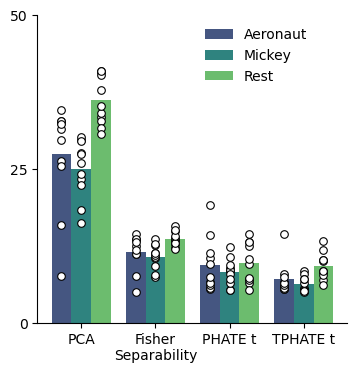

In [23]:
df = pd.read_csv('RestMovie/results/searchlight_avg_dimensionality.csv')


task_order = ['Aeronaut','Mickey','Rest']
metric_order = ['PCA','MLE','PHATE_T','TPHATE']
met_names = ['PCA','Fisher\nSeparability','PHATE t','TPHATE t']

for met in metric_order:
    for task1,task2 in itertools.combinations(task_order, 2):
        print(ttest_rel(df[(df['task'] == task1) & (df['metric'] == met)]['average_dim'].values, 
                        df[(df['task'] == task2) & (df['metric'] == met)]['average_dim'].values),
              met,task1,task2)
    
    
fig,ax=plt.subplots(figsize=(4, 4))
g = sns.barplot(x='metric', y='average_dim', ci=None, hue='task', 
                data=df, order=metric_order, hue_order=task_order, palette='viridis')
# plt.xticks(rotation=90)
g.set(xlabel='', xticklabels=met_names, ylabel='',ylim=[0,50],yticks=[0,25,50])
#sns.move_legend(ax, "upper right",frameon=False)
sns.move_legend(
    ax, "upper left",
    bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False,
)

for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[c] 
        points = df[(df['metric']==meth) & (df['task']==task)]['average_dim'].values

        ax.scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=1,
                   zorder=10, linewidths=0.8, 
                   s=30, c="white")
sns.despine()

plt.savefig('ccn_plots/id_rm_bar_ph.pdf', bbox_inches = "tight",transparent=True, format='pdf')


Ttest_relResult(statistic=-3.546019631989521, pvalue=0.0010352679486832815) Black Bronx lPCA
Ttest_relResult(statistic=0.3782534061426017, pvalue=0.7072935158372582) Black Forgot lPCA
Ttest_relResult(statistic=-3.8825018562708684, pvalue=0.00038846810731327317) Black Pieman lPCA
Ttest_relResult(statistic=4.09758518534686, pvalue=0.00020432302096378883) Bronx Forgot lPCA
Ttest_relResult(statistic=-0.7553594673933356, pvalue=0.4545712808410649) Bronx Pieman lPCA
Ttest_relResult(statistic=-5.035920194468134, pvalue=1.1181320872205185e-05) Forgot Pieman lPCA
Ttest_relResult(statistic=1.5056529234247973, pvalue=0.14021340462493473) Black Bronx MLE
Ttest_relResult(statistic=-0.9117202397943069, pvalue=0.3675173776694496) Black Forgot MLE
Ttest_relResult(statistic=2.765024876163291, pvalue=0.008649172238117493) Black Pieman MLE
Ttest_relResult(statistic=-2.4315508988701926, pvalue=0.0197293556435072) Bronx Forgot MLE
Ttest_relResult(statistic=1.8642348809221916, pvalue=0.06982849310439104) Br

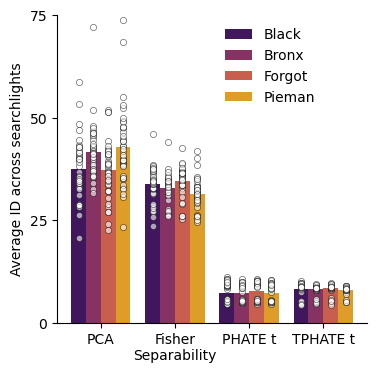

In [44]:
df = pd.read_csv('Narratives/results/searchlight_avg_dimensionality.csv')
task_order = ['Black','Bronx','Forgot','Pieman']
metric_order = ['lPCA','MLE',"PHATE",'OPTT']
met_names = ['PCA','Fisher\nSeparability',"PHATE t", 'TPHATE t']

for met in metric_order:
    for task1,task2 in itertools.combinations(task_order, 2):
        vec1 = df[(df['task'] == task1) & (df['metric'] == met)]['average_dim'].values
        vec2 = df[(df['task'] == task2) & (df['metric'] == met)]['average_dim'].values
        print(ttest_rel(vec1, vec2), task1, task2, met)        

fig,ax=plt.subplots(figsize=(4,4))
g = sns.barplot(x='metric', y='average_dim', ci=None, hue='task', data=df, order=metric_order, hue_order=task_order, palette='inferno')
# plt.xticks(rotation=90)
g.set(xlabel='', xticklabels=met_names, ylabel='Average ID across searchlights',ylim=[0,75],yticks=[0,25,50,75])

sns.move_legend(
    ax, "upper left",
    bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False,
)

for container, task in zip(g.containers, task_order):    
    for c, patch in enumerate(container):
        w = patch.get_width()/2
        x, y = patch.xy
        meth = metric_order[c] 
        points = df[(df['metric']==meth) & (df['task']==task)]['average_dim'].values

        ax.scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=0.6,
                   zorder=10, linewidths=0.5, s=20, c="white")
sns.despine()
plt.savefig('ccn_plots/id_narratives_bar.pdf', bbox_inches = "tight",transparent=True, format='pdf')



In [123]:
for typ, dic in NAR_RES.items():
    for task, values in dic.items():
        v = np.mean(values, axis=0)
        print(typ, task, np.min(v), np.max(v), np.mean(v))
for typ, dic in RM_RES.items():
    for task, values in dic.items():
        v = np.mean(values, axis=0)
        print(typ, task, np.min(v), np.max(v), np.mean(v))

OPTT Black 6.975 12.1 8.335924144247056
OPTT Bronx 6.875 11.975 8.197874896600622
OPTT Forgot 7.125 12.2 8.426923720801986
OPTT Pieman 6.65 11.425 8.113310946547445
PCA Black 30.725 193.3 126.46961215385828
PCA Bronx 33.075 166.1 114.69357889864891
PCA Forgot 29.8 196.65 127.6935486174026
PCA Pieman 32.025 142.175 101.79198851774534
lPCA Black 6.925 152.375 37.579907777602706
lPCA Bronx 6.375 156.4 41.66336510812621
lPCA Forgot 6.7 156.85 37.234473106314255
lPCA Pieman 7.025 145.6 42.78392902863671
FISHERS Black 5.384158091905003 18.4316469033778 9.54515854769377
FISHERS Bronx 4.529163319704873 21.62992147455146 9.669689329907563
FISHERS Forgot 5.530026766638862 20.25534221416396 9.936613086963305
FISHERS Pieman 5.323894824978375 18.73143957014018 9.829050774638537
DIFFERENCE_OPTT Rest-Mickey -2.090909090909091 15.181818181818182 7.270482667083473
DIFFERENCE_OPTT Rest-Aeronaut -5.363636363636363 15.090909090909092 5.377405071886314
DIFFERENCE_OPTT Aeronaut-Mickey -5.090909090909091 8.9

# plot opt t stat maps

In [610]:
ABCD = NAR_RES['OPTT']
nar_mask = narutils.get_intersect_mask()
vmin = 0
vmax = 12
cmap=utils.get_brain_cmap()
for stim, im in ABCD.items():
    v = np.mean(im,axis=0)
    vol = tc.vec2vol(v, nar_mask)
    plotting.plot_img_on_surf(vol, 
                                  views=['lateral'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=f'ccn_plots/{stim}_opt_final.png',
                                  darkness=0.8, 
                                  threshold=1,
                              vmax=vmax, dpi=300,
                                 )

In [9]:
ABCD = RM_RES['OPTT']
rm_mask = utils.get_intersect_mask()
vmin = 0
vmax = 35
cmap=utils.get_brain_cmap(viridis_white)
for stim, im in ABCD.items():
    if stim == 'Rest':
        v = np.mean(im,axis=0)
        vol = tc.vec2vol(v, rm_mask)
        plotting.plot_img_on_surf(vol, 
                                      views=['lateral','medial'], 
                                      cmap=cmap, 
                                      inflate=True, 
                                      bg_on_data=False, 
                                              alpha=0.8,
                                      output_file=f'ccn_plots/{stim}_opt_final.png',
                                      darkness=0.8, 
                                      threshold=vmin,
                                  vmax=35,
                                  dpi=300
                                     )

In [608]:
ABCD = RM_RES['OPTT']
rm_mask = utils.get_intersect_mask()
vmin = 0
vmax = 35
cmap=utils.get_brain_cmap(viridis_white)
for stim, im in ABCD.items():
    v = np.mean(im,axis=0)
    vol = tc.vec2vol(v, rm_mask)
    plotting.plot_img_on_surf(vol, 
                                  views=['lateral'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=f'ccn_plots/{stim}_opt_final.png',
                                  darkness=0.8, 
                                  threshold=vmin,
                              vmax=35,
                              dpi=300
                                 )

In [ ]:
ordering = {'camcan':['movie','smt','rest'], 'rest_movie':['aeronaut','mickey','rest'], 'narratives':['black','bronx','forgot','piemanpni']}
xorder = ['lPCA', 'FisherS', 'MLE', 'MiND_ML',  'TPHATE_SE', 'optt']
for k,v in ordering.items():
    
    subdf = df[df['dataset'] == k]
    fig,ax=plt.subplots()
    g = sns.barplot(data=subdf, hue='task', ci=None, hue_order=v, x='metric', y='average_score', order=xorder, ax=ax, palette='Set3')
    plt.xticks(rotation=90)
    g.set(xlabel='', title=f'IDE methods for {k}', ylabel='ID')
    
    for container, task in zip(g.containers, v):    
        for c, patch in enumerate(container):
            w = patch.get_width()/2
            x, y = patch.xy
            meth = xorder[c] 
            points = subdf[(subdf['metric']==meth) & (subdf['task']==task)]['average_score'].values

            ax.scatter(x=np.repeat(x+w, len(points)), y=points, edgecolors='k', alpha=0.6,
                       zorder=10, linewidths=0.3, s=16, c="white")
    
    
    sns.despine()


# ISC correlated with IDE

In [503]:
from scipy.spatial.distance import cdist
all_mickey = np.load('RestMovie/results/all_subject_arrays/mickey_tphate_optt_knn20_smooth_window1_all_subject_results.npy')
all_aero = np.load('RestMovie/results/all_subject_arrays/aeronaut_tphate_optt_knn20_smooth_window1_all_subject_results.npy')
rm_ide = np.array(np.array([np.mean(all_aero,axis=0), np.mean(all_mickey,axis=0)]))
avg_ide = np.mean(rm_ide,axis=0)
print(avg_ide.shape)

mickey_isc = np.load('RestMovie/results/ISC/MICKEY_all_subjects_results.npy')
aero_isc = np.load('RestMovie/results/ISC/AERONAUT_all_subjects_results.npy')
rm_isc = np.array(np.array([np.mean(aero_isc,axis=0), np.mean(mickey_isc,axis=0)]))
avg_isc = np.mean(rm_isc, axis=0)

print(avg_isc.shape)

(70958,)
(70958,)


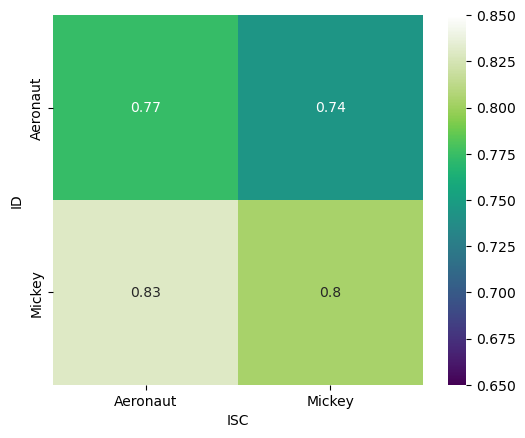

In [600]:
g=sns.heatmap(stats.spearmanr(rm_isc.T, rm_ide.T)[0][2:, :2], vmin=0.65, vmax=0.85, cmap=viridis_white, square=True, annot=True)
label=["Aeronaut",'Mickey']
g.set(xlabel='ISC',xticklabels=label,yticklabels=label, ylabel='ID')
plt.savefig('ccn_plots/rm_correlation_heatmap.pdf', bbox_inches = "tight", transparent=True, format='pdf')

In [310]:
# diag = np.diag_indices(11)
# C_ma = 1-cdist(mickey_isc, all_aero, 'correlation')
self_cma = [stats.spearmanr(mickey_isc[i], all_aero[i])[0] for i in range(11)]

C_am = 1-cdist(all_mickey, aero_isc, 'correlation')
self_cam = [stats.spearmanr(aero_isc[i], all_mickey[i])[0] for i in range(11)]

df=pd.DataFrame({'subjects':np.arange(11), 'comparison': np.repeat('MISC,AIDE',11), 'score':self_cma})
df=pd.concat([df, pd.DataFrame({'subjects':np.arange(11), 'comparison': np.repeat('AISC,MIDE',11), 'score':self_cam})])


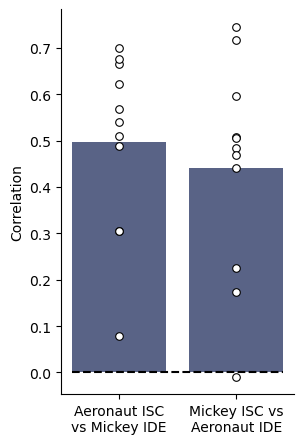

In [490]:
# diag = np.diag_indices(11)
# C_ma = 1-cdist(mickey_isc, all_aero, 'correlation')
# self_cma = [stats.spearmanr(mickey_isc[i], all_aero[i])[0] for i in range(11)]

# C_am = 1-cdist(all_mickey, aero_isc, 'correlation')
# self_cam = [stats.spearmanr(aero_isc[i], all_mickey[i])[0] for i in range(11)]

# df=pd.DataFrame({'subjects':np.arange(11), 'comparison': np.repeat('MISC,AIDE',11), 'score':self_cma})
# df=pd.concat([df, pd.DataFrame({'subjects':np.arange(11), 'comparison': np.repeat('AISC,MIDE',11), 'score':self_cam})])



xlabels = ['Aeronaut ISC\nvs Mickey IDE', 'Mickey ISC vs\nAeronaut IDE', ]
xorder = ['AISC,MIDE', 'MISC,AIDE', ]
w=0.4
fig,ax=plt.subplots(figsize=(3,5))
g = sns.barplot(x='comparison', y='score', data=df, color='#515F8D',ax=ax,order=xorder, ci=None)
g.set(xticklabels=xlabels, ylabel='Correlation',xlabel='')

points = df[(df['comparison']=='AISC,MIDE')]['score'].values
ax.scatter(x=np.repeat(1-w*2.5, len(points)), y=points, edgecolors='k', alpha=1,
                   zorder=10, linewidths=0.8, s=30, c="white")
points = df[(df['comparison']=='MISC,AIDE')]['score'].values

ax.scatter(x=np.repeat(2.5*w, len(points)), y=points, edgecolors='k', alpha=1,
                   zorder=10, linewidths=0.8, s=30, c="white")
ax.hlines(0,1-w*2.5-w, 2.5*w+w, 'k','--')
sns.despine()
plt.savefig('ccn_plots/correlation_bar.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [477]:
nar_ide = np.array([np.mean(x,axis=0) for x in [all_black, all_bronx, all_forgot, all_pieman]])
black_isc = np.load('Narratives/results/ISC/BLACK_ISC_all_subjects_results.npy')
bronx_isc = np.load('Narratives/results/ISC/BRONX_ISC_all_subjects_results.npy')
forgot_isc = np.load('Narratives/results/ISC/FORGOT_ISC_all_subjects_results.npy')
pieman_isc = np.load('Narratives/results/ISC/PIEMANPNI_ISC_all_subjects_results.npy')

nar_isc = np.array([np.mean(x,axis=0) for x in [black_isc, bronx_isc, forgot_isc, pieman_isc]])


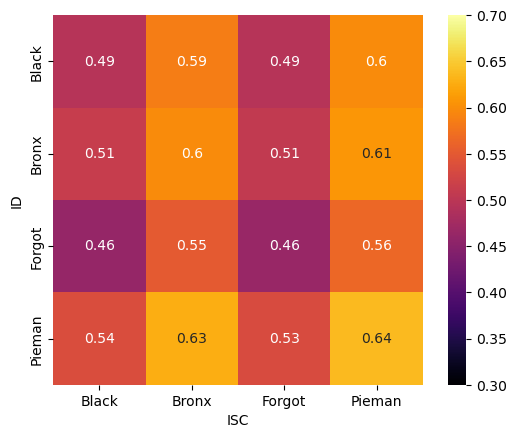

In [486]:
g=sns.heatmap(stats.spearmanr(nar_isc.T, nar_ide.T)[0][4:, :4], vmin=0.3, vmax=0.7, cmap='inferno', square=True, annot=True)
label=['Black','Bronx','Forgot','Pieman']
g.set(xlabel='ISC',xticklabels=label,yticklabels=label, ylabel='ID')
plt.savefig('ccn_plots/correlation_heatmap.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [316]:
df1 = pd.DataFrame({'IDE':np.mean(nar_ide,axis=0), 'ISC':np.mean(nar_isc,axis=0)})
rm_ide = np.squeeze(np.mean(np.mean(np.array([all_aero, all_mickey]),axis=0),axis=0))
rm_isc = np.squeeze(np.mean(np.mean(np.array([aero_isc, mickey_isc]),axis=0),axis=0))
''
df2 = pd.DataFrame({'SL':np.arange(len(rm_ide)), 'IDE': rm_ide , 'ISC': rm_isc})


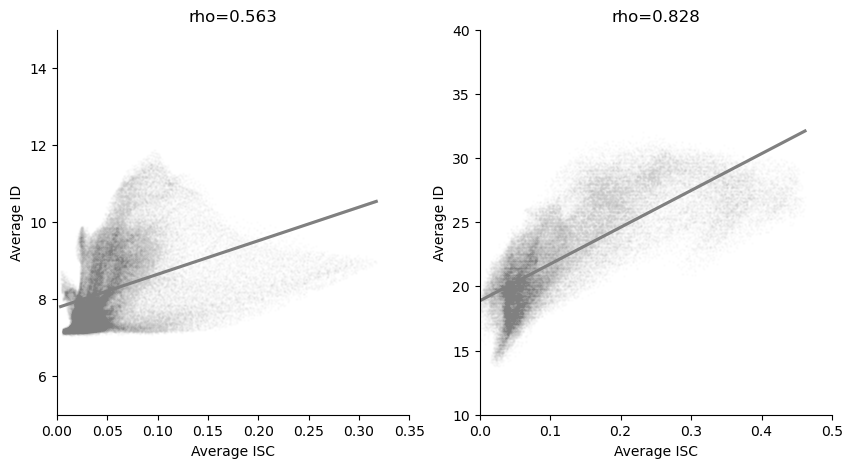

In [322]:
fig,ax=plt.subplots(1,2, figsize=(10,5))
g = sns.regplot(data=df2, x='ISC', y='IDE',  color='gray', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[1])
r,p = stats.spearmanr(df2['ISC'],df2['IDE'])

g.set( xlabel='Average ISC', ylabel='Average ID', title=f'rho={np.round(r, 3)}', ylim=[10,40], xlim=[0,0.5])

g = sns.regplot(data=df1, x='ISC', y='IDE',  color='gray', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[0])
r,p = stats.spearmanr(df1['ISC'],df1['IDE'])

g.set( xlabel='Average ISC', ylabel='Average ID', title=f'rho={np.round(r, 3)}', ylim=[5,15], xlim=[0,0.35])
sns.despine()
plt.savefig('ccn_plots/scatterplots.pdf', bbox_inches = "tight",transparent=True, format='pdf')



In [206]:
np.mean()

sns.scatterplot()

0.4072314728765489

# ISC results

KeyboardInterrupt: 

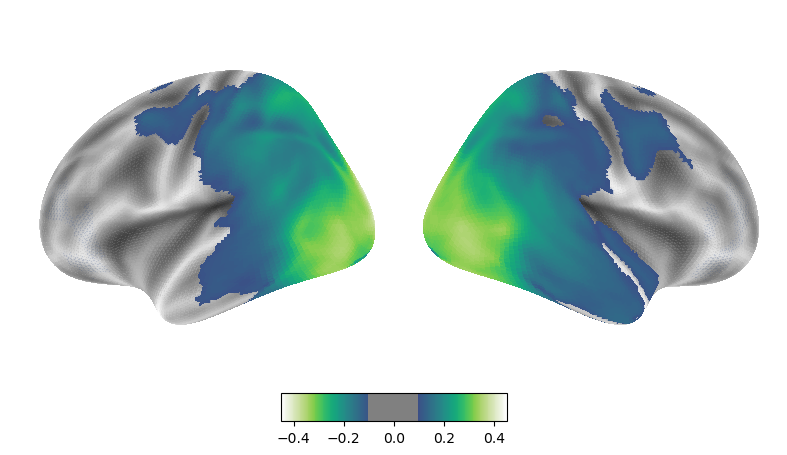

In [11]:
RM_ISC = {'Aeronaut':'RestMovie/results/ISC/group_average_AERONAUT_ISC_whole_brain_SL_rad5.nii.gz',
         'Mickey':'RestMovie/results/ISC/group_average_MICKEY_ISC_whole_brain_SL_rad5.nii.gz'}

NAR_ISC = {'Bronx':'Narratives/results/ISC/group_average_BRONX_ISC_whole_brain_SL_rad5.nii.gz',
         'Black':'Narratives/results/ISC/group_average_BLACK_ISC_whole_brain_SL_rad5.nii.gz',
         'Forgot':'Narratives/results/ISC/group_average_FORGOT_ISC_whole_brain_SL_rad5.nii.gz',
         'Pieman':'Narratives/results/ISC/group_average_PIEMANPNI_ISC_whole_brain_SL_rad5.nii.gz'}

NAR_MASK=narutils.get_intersect_mask()
RM_MASK = utils.get_intersect_mask()

vmin = 0.1
vmax = 0.4
cmap=utils.get_brain_cmap()
cmap_v = utils.get_brain_cmap(viridis_white)
for stim, im in RM_ISC.items():
    plotting.plot_img_on_surf(im, 
                                  views=['lateral'], 
                                  cmap=cmap_v, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=f'ccn_plots/{stim}_ISC_final.png',
                                  darkness=0.8, 
                                  threshold=vmin,
                              vmax=0.45, dpi=300
                                 )
    
# for stim, im in NAR_ISC.items():
#     plotting.plot_img_on_surf(im, 
#                                   views=['lateral'], 
#                                   cmap=cmap, 
#                                   inflate=True, 
#                                   bg_on_data=False, 
#                                           alpha=0.8,
#                                   output_file=f'ccn_plots/{stim}_ISC_final.png',
#                                   darkness=0.8, 
#                                   threshold=vmin,
#                               vmax=0.35, dpi=300
#                                  )

# rest movie subtraction

In [157]:
RM_ISC['Aeronaut']

'RestMovie/results/ISC/group_average_AERONAUT_ISC_whole_brain_SL_rad5.nii.gz'

In [12]:
rest_aero = np.mean(all_rest -  all_aero,axis=0)
rest_mick = np.mean(all_rest -  all_mickey, axis=0)
isc_aero = nib.load(RM_ISC['Aeronaut']).get_fdata()[coords]
isc_mickey = nib.load(RM_ISC['Mickey']).get_fdata()[coords]


NameError: name 'coords' is not defined

In [249]:
# create aeronaut isc map
aero_isc_fns = glob.glob(f'{RM_RESULTS_DIR}/ISC/AERONAUT*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.mean(np.vstack([np.load(f) for f in aero_isc_fns]),axis=0)
# find the top 5 percent
q95=np.percentile(data, 95)
q5 = np.percentile(data, 5)
coords_95 = np.where(data > q95)
coords_5 = np.where(data < q5)
print(q95, q5)
aero_isc_top_bot_mask = np.zeros_like(data)
aero_isc_top_bot_mask[coords_95] = 1
aero_isc_top_bot_mask[coords_5] = -1

mickey_isc_fns = glob.glob(f'{RM_RESULTS_DIR}/ISC/MICKEY*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.mean(np.vstack([np.load(f) for f in mickey_isc_fns]),axis=0)
# find the top 5 percent
q95=np.percentile(data, 95)
q5 = np.percentile(data, 5)
coords_95 = np.where(data > q95)
coords_5 = np.where(data < q5)
print(q95, q5)
mickey_isc_top_bot_mask = np.zeros_like(data)
mickey_isc_top_bot_mask[coords_95] = 1
mickey_isc_top_bot_mask[coords_5] = -1




0.33645061422883976 0.02960600388133273
0.36714417521490006 0.014871766767038722


In [256]:
print('bot95',np.mean(rest_mick[aero_isc_top_bot_mask==-1]),np.std(rest_mick[aero_isc_top_bot_mask==-1]))
print('top95',np.mean(rest_mick[aero_isc_top_bot_mask==1]),np.std(rest_mick[aero_isc_top_bot_mask==1]))

bot95 8.576406682381881 2.6652022016425176
top95 4.489443476478426 2.2663224078283526


In [ ]:
df1 = pd.DataFrame({'rest_aero':rest_aero[aero_isc_top_bot_mask==-1]})
df1['ISC_group'] = 'bottom5_aero_isc'

df2 = pd.DataFrame({'rest_aero':rest_aero[aero_isc_top_bot_mask==1]})
df1['ISC_group'] = 'top5_aero_isc'

df = pd.concat([df1, df2])

bot95 6.057292200471457 2.2823680124492824
top95 2.6505841959618737 2.7708302061670755
Ttest_indResult(statistic=-56.51901473076758, pvalue=0.0)
bot95 7.9451675719995905 2.655772128586197
top95 5.285512965050732 2.5258688528856688
Ttest_indResult(statistic=-43.21824031411904, pvalue=0.0)


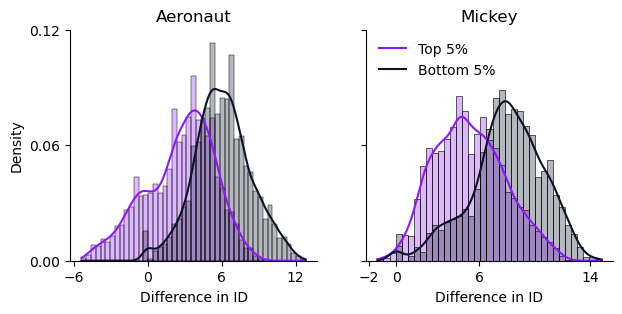

In [328]:
fig,ax=plt.subplots(1,2,figsize=(7,3))

print('bot95',np.mean(rest_aero[aero_isc_top_bot_mask==-1]),np.std(rest_aero[aero_isc_top_bot_mask==-1]))
print('top95',np.mean(rest_aero[aero_isc_top_bot_mask==1]),np.std(rest_aero[aero_isc_top_bot_mask==1]))
print(ttest_ind(rest_aero[aero_isc_top_bot_mask==1], rest_aero[aero_isc_top_bot_mask==-1], alternative='less'))

df1 = pd.DataFrame({'rest_aero':rest_aero[aero_isc_top_bot_mask==-1]})
df1['ISC_group'] = 'bottom5_aero_isc'

df2 = pd.DataFrame({'rest_aero':rest_aero[aero_isc_top_bot_mask==1]})
df2['ISC_group'] = 'top5_aero_isc'

df = pd.concat([df1, df2]).reset_index()
g=sns.histplot(data=df, x="rest_aero", hue="ISC_group", kde=True, alpha=0.3,
             palette=['#0A1328','#9215FF'],stat='density',
             hue_order=['bottom5_aero_isc','top5_aero_isc'],ax=ax[0],legend=False)

g.set(xlabel='Difference in ID', ylabel='Density', xticks=[-6, 0, 6, 12], yticks=[0,0.06, 0.12],
      title='Aeronaut')



df1 = pd.DataFrame({'rest_mick':rest_mick[mickey_isc_top_bot_mask==-1]})
df1['ISC_group'] = 'bottom5_mick_isc'

df2 = pd.DataFrame({'rest_mick':rest_mick[mickey_isc_top_bot_mask==1]})
df2['ISC_group'] = 'top5_mick_isc'

df = pd.concat([df1, df2]).reset_index()
print('bot95',np.mean(rest_mick[mickey_isc_top_bot_mask==-1]),np.std(rest_mick[mickey_isc_top_bot_mask==-1]))
print('top95',np.mean(rest_mick[mickey_isc_top_bot_mask==1]),np.std(rest_mick[mickey_isc_top_bot_mask==1]))
print(ttest_ind(rest_mick[mickey_isc_top_bot_mask==1],rest_mick[mickey_isc_top_bot_mask==-1], alternative='less'))


g=sns.histplot(data=df, x="rest_mick", hue="ISC_group", kde=True, alpha=0.3,
             palette=['#0A1328','#9215FF'],stat='density',
             hue_order=['bottom5_mick_isc','top5_mick_isc'],ax=ax[1],legend=True)

sns.move_legend(
    ax[1], "upper left", ncol=1, title=None, frameon=False, labels=['Top 5%', 'Bottom 5%']
)


g.set(xlabel='Difference in ID', ylabel='', xticks=[-2, 0, 6, 14], yticks=[0,0.06, 0.12],yticklabels=[],title='Mickey')

sns.despine()

plt.savefig('ccn_plots/histograms.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [278]:
np.sum(aero_isc_top_bot_mask == -1), np.sum(aero_isc_top_bot_mask == 1)

(3548, 3548)

In [280]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold


logisticRegr = LogisticRegression()
folder = KFold(n_splits=10)
scores = []
indices = np.squeeze(np.where(incl_vox == True)[0])

for train,test in folder.split(indices):
    X_train = rest_aero[train].reshape(-1,1)
    y_train = [aero_isc_top_bot_mask[i] for i in train]#isc_aero[train]
    X_test = rest_aero[test].reshape(-1, 1)
    y_test = [aero_isc_top_bot_mask[i] for i in test]#isc_aero[test]
    scores.append(logisticRegr.fit(X_train,y_train).score(X_test,y_test))
    
print(np.mean(scores))
    



0.9694107948111803


In [272]:
incl_vox = aero_isc_top_bot_mask!=0

sns.regplot(x=rest_aero[incl_vox], y=isc_aero[incl_vox], logistic=True)

# score the log reg 
logisticRegr = LogisticRegression()
folder = KFold(n_splits=10)
scores = []
indices = np.squeeze(np.where(incl_vox == True)[0])

for train,test in folder.split(indices):
    X_train = rest_mickey[train].reshape(-1,1)
    y_train = [aero_isc_top_bot_mask[i] for i in train]#isc_aero[train]
    X_test = rest_aero[test].reshape(-1, 1)
    y_test = [aero_isc_top_bot_mask[i] for i in test]#isc_aero[test]
    scores.append(logisticRegr.fit(X_train,y_train).score(X_test,y_test))
    
print(np.mean(scores))


(7096,)

In [287]:
rest_mickey.shape

(11, 70958)

0.9706782017918512


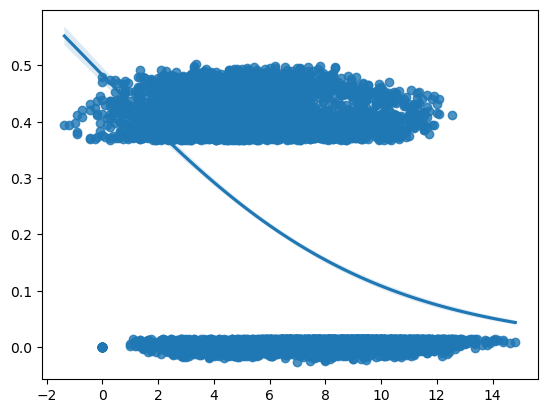

In [289]:
incl_vox = mickey_isc_top_bot_mask!=0

sns.regplot(x=rest_mick[incl_vox], y=isc_mickey[incl_vox], logistic=True)

# score the log reg 
logisticRegr = LogisticRegression()
folder = KFold(n_splits=10)
scores = []
indices = np.squeeze(np.where(incl_vox == True)[0])

for train,test in folder.split(indices):
    X_train = rest_mick[train].reshape(-1,1)
    y_train = [mickey_isc_top_bot_mask[i] for i in train]#isc_aero[train]
    X_test = rest_mick[test].reshape(-1, 1)
    y_test = [mickey_isc_top_bot_mask[i] for i in test]#isc_aero[test]
    scores.append(logisticRegr.fit(X_train,y_train).score(X_test,y_test))
    
print(np.mean(scores))


0.9694107948111803


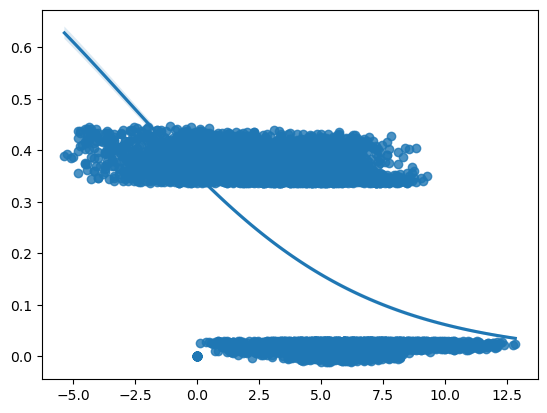

In [288]:
incl_vox = aero_isc_top_bot_mask!=0

sns.regplot(x=rest_aero[incl_vox], y=isc_aero[incl_vox], logistic=True)

# score the log reg 
logisticRegr = LogisticRegression()
folder = KFold(n_splits=10)
scores = []
indices = np.squeeze(np.where(incl_vox == True)[0])

for train,test in folder.split(indices):
    X_train = rest_aero[train].reshape(-1,1)
    y_train = [aero_isc_top_bot_mask[i] for i in train]#isc_aero[train]
    X_test = rest_aero[test].reshape(-1, 1)
    y_test = [aero_isc_top_bot_mask[i] for i in test]#isc_aero[test]
    scores.append(logisticRegr.fit(X_train,y_train).score(X_test,y_test))
    
print(np.mean(scores))


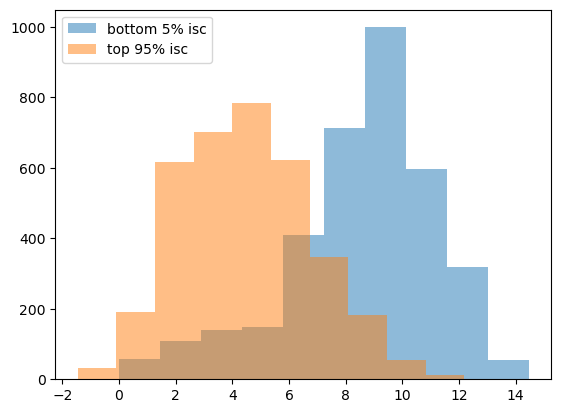

In [251]:
plt.hist(rest_mick[aero_isc_top_bot_mask==-1],alpha=0.5, label='bottom 5% isc')
plt.hist(rest_mick[aero_isc_top_bot_mask==1],alpha=0.5,label='top 95% isc')
plt.legend()

<AxesSubplot:>

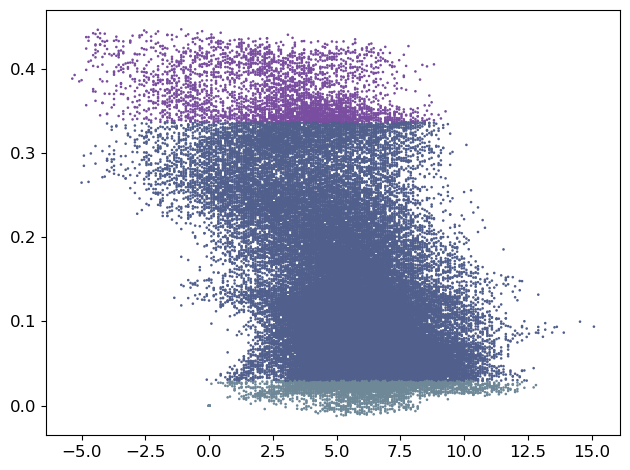

In [245]:
import scprep

color_dic = {0:'#515F8D', 1:'#794D9F', -1:'#6E8898'}

scprep.plot.scatter2d((rest_aero,isc_aero), c=[color_dic[i] for i in mask])
# g = sns.regplot(y=rest_aero, x=isc_aero,  color=['#515F8D', ''], order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[0])


In [230]:
x = rest_aero
y = isc_aero
c=[color_dic[i] for i in aero_isc_mask_coords]



<AxesSubplot:>

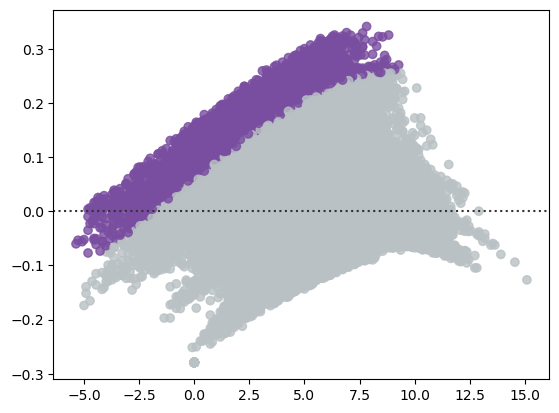

In [233]:
sns.residplot(x=x,y=y,order=3,scatter_kws={'color':c})

In [ ]:
mick_isc_mask_coords

In [ ]:

sns.regplot(x=x, y=y, data=df, logistic=True, ci=None)

In [238]:
stats.pearsonr(rest_aero,isc_mickey), stats.pearsonr(rest_mick**2,isc_aero), 

((-0.38046951331123924, 0.0), (-0.4391706819022565, 0.0))

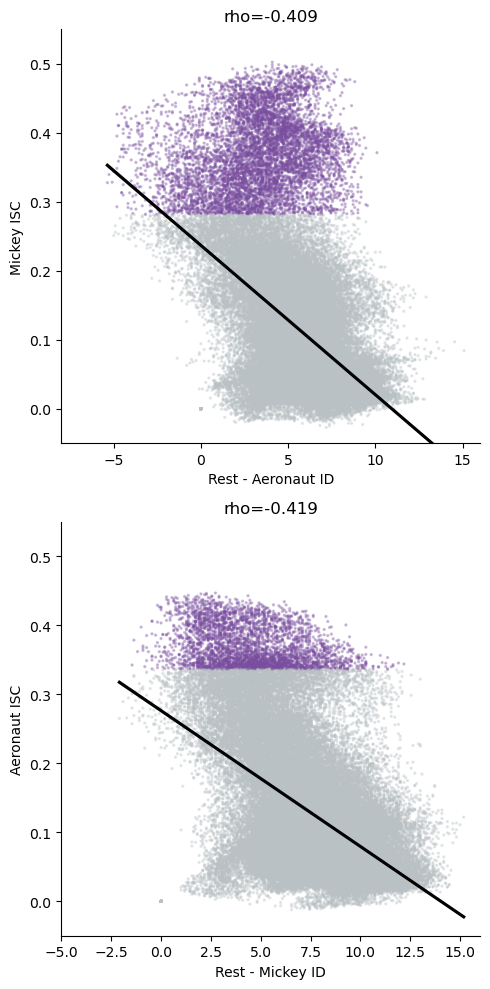

In [234]:
fig,ax=plt.subplots(2,1, figsize=(5, 10))

color_dic = {0:'#B9C1C4', 1:'#794D9F'}
cma = [color_dic[i] for i in mick_isc_mask_coords]

g = sns.regplot(x=rest_aero, y=isc_mickey,   order=1,color='k', scatter_kws={'alpha':0.3, 's':2,
                                                                 'color':cma}, ax=ax[0])
r,p = stats.spearmanr(rest_aero,isc_mickey)
g.set( ylabel='Mickey ISC', xlabel='Rest - Aeronaut ID', title=f'rho={np.round(r, 3)}', ylim=[-0.05,0.55], xlim=[-8,16])

cma = [color_dic[i] for i in aero_isc_mask_coords]

g = sns.regplot(x=rest_mick, y=isc_aero,  color ='k' , order=1, scatter_kws={'alpha':0.3, 
                                                                             's':2, 'color':cma}, ax=ax[1])
r,p = stats.spearmanr(rest_mick,isc_aero)
g.set( ylabel='Aeronaut ISC', xlabel='Rest - Mickey ID', title=f'rho={np.round(r, 3)}', ylim=[-0.05,0.55], xlim=[-5,16])
fig.tight_layout()
sns.despine()

In [ ]:
# split data to pair the bins - 90th % vs 10th % ISC voxels and then logistic regression between the two 

# does AIC of quadratic fit better fit than the linear regression - when you fit a linear regression, does the AIC get lower when you square (x) side

In [ ]:
fig,ax=plt.subplots(2,1, figsize=(5, 10))

color_dic = {0:'#B9C1C4', 1:'#794D9F'}

cma = [color_dic[i] for i in aero_isc_mask_coords]
g = sns.regplot(x=rest_aero, y=isc_aero,   order=1,color='k', scatter_kws={'alpha':0.3, 's':2,
                                                                 'color':cma}, ax=ax[0])
r,p = stats.spearmanr(rest_aero,isc_aero)
g.set( ylabel='Aeronaut ISC', xlabel='Rest - Aeronaut ID', title=f'rho={np.round(r, 3)}', ylim=[-0.1,0.55], xlim=[-8,16])

cma = [color_dic[i] for i in mick_isc_mask_coords]
g = sns.regplot(x=rest_mick, y=isc_mickey,  color ='k' , order=1, scatter_kws={'alpha':0.3, 
                                                                             's':2, 'color':cma}, ax=ax[1])
r,p = stats.spearmanr(rest_mick,isc_mickey)
g.set( ylabel='Mickey ISC', xlabel='Rest - Mickey ID', title=f'rho={np.round(r, 3)}', ylim=[-0.1,0.55], xlim=[-5,16])
fig.tight_layout()
sns.despine()

2.3725749391959194 2.3725749391959194


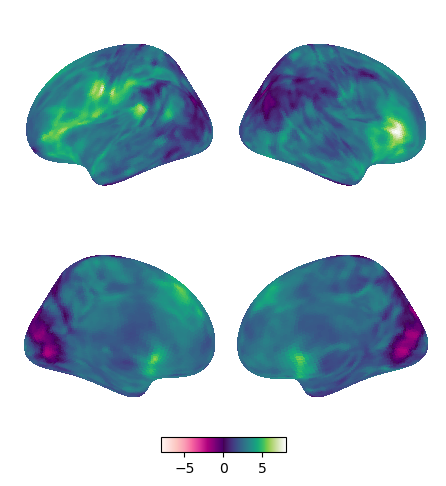

In [150]:
t, p = ttest_ind(all_rest, all_aero)

mask = utils.get_intersect_mask()
coords = np.where(mask.get_fdata() == 1)
t_vol_rest_aero = tc.vec2vol(t, mask)
alpha=0.05
fdr_t = fdr_threshold(t, alpha/2)
thresholded_img, threshold = threshold_stats_img(stat_img=t_vol_rest_aero, height_control='fdr',
                                                 mask_img=mask, alpha=alpha, cluster_threshold=20)
print(threshold, fdr_t)
plotting.plot_img_on_surf(t_vol_rest_aero, threshold=0, inflate=True, cmap=viridis_rdpu_cmap)

# now create a mask based on this
thresholding_mask = math_img(f'np.where(img > {fdr_t}, 1, 0)', img=t_vol_rest_aero)
# multiply with the average volume
rest_aero_avg = np.mean(rest_aero, axis=0)
rest_aero_avg_volume = tc.vec2vol(rest_aero_avg, mask)
# multiply the masks
avg_vol_masked =  math_img(f'img * img2', img=rest_aero_avg_volume, img2=thresholding_mask)
v = avg_vol_masked.get_fdata()
dim_threshold = v[v!=0].min()
viridis_rdpu_cmap = ListedColormap(colors_combined, name='ViridisWhiteRdPu')
plotting.plot_img_on_surf(avg_vol_masked, threshold=dim_threshold, inflate=True,vmax=16, 
                          cmap=viridis_rdpu_cmap, title='Rest - Aero optimal t', dpi=300, 
                          output_file='ccn_plots/rest_minus_aeronaut_optt_thresholded.png')


# combine cmaps to show difference adn ISC

# create aeronaut isc map
aero_isc_fns = glob.glob(f'{RM_RESULTS_DIR}/ISC/AERONAUT*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.mean(np.vstack([np.load(f) for f in aero_isc_fns]),axis=0)
# find the top 5 percent
q=np.percentile(data, 90)
bindata = np.where(data > q, 1, 0)
aero_isc_mask_coords = np.where(bindata >= 1, 1, 0)
brain_mask_aero = tc.vec2vol(aero_isc_mask_coords, mask)
# create a combined image
new_vol = np.zeros_like(mask.get_fdata())
# place dim diff data into this
new_vol += avg_vol_masked.get_fdata()
c = np.where(brain_mask_aero.get_fdata() == 1)
new_vol[c] = -5.2

# # convert to nifti
nii = Nifti1Image(new_vol, affine=mask.affine)

# create a new colorbar
first = viridis_white
second = plt.cm.gnuplot_r
colors1 = first(np.linspace(0., 1, 128))
colors2 = second(np.linspace(0, 1, 128))
NEW_CMAP = np.vstack((colors2,colors1))
NEW_CMAP = ListedColormap(NEW_CMAP)
plotting.plot_img_on_surf(nii, views=['lateral','medial'], threshold=dim_threshold, inflate=True,vmax=16, 
                          cmap=NEW_CMAP, title='Rest - Aero optimal t', dpi=300, 
                          output_file='ccn_plots/rest_minus_aeronaut_optt_thresholded_isc_overlay.png')

In [152]:
t, p = ttest_ind(all_rest, all_mickey)

mask = utils.get_intersect_mask()
coords = np.where(mask.get_fdata() == 1)
t_vol_rest_mickey = tc.vec2vol(t, mask)
alpha=0.01
fdr_t = fdr_threshold(t, alpha/2)
thresholded_img, threshold = threshold_stats_img(stat_img=t_vol_rest_mickey, height_control='fdr',
                                                 mask_img=mask, alpha=alpha, cluster_threshold=30)
print(threshold, fdr_t)
#plotting.plot_img_on_surf(thresholded_img, threshold=threshold, cmap=viridis_rdpu_cmap, inflate=True)

# now create a mask based on this
thresholding_mask = math_img(f'np.where(img > {fdr_t}, 1, 0)', img=t_vol_rest_mickey)
# multiply with the average volume
rest_mickey_avg = np.mean(rest_mickey, axis=0)
rest_mickey_avg_volume = tc.vec2vol(rest_mickey_avg, mask)
# multiply the masks
avg_vol_masked =  math_img(f'img * img2', img=rest_mickey_avg_volume, img2=thresholding_mask)
v = avg_vol_masked.get_fdata()
dim_threshold = v[v!=0].min()

plotting.plot_img_on_surf(avg_vol_masked, threshold=dim_threshold, 
                          cmap=viridis_rdpu_cmap, inflate=True, 
                          vmax=16, 
                          title='Rest - Mickey optimal t', dpi=300, 
                          output_file='ccn_plots/rest_minus_mickey_optt_thresholded.png')

# combine cmaps to show difference adn ISC

# create aeronaut isc map
mick_isc_fns = glob.glob(f'{RM_RESULTS_DIR}/ISC/MICKEY*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.mean(np.vstack([np.load(f) for f in mick_isc_fns]),axis=0)
# find the top 5 percent
q=np.percentile(data, 90)
bindata = np.where(data > q, 1, 0)
mick_isc_mask_coords = np.where(bindata >= 1, 1, 0)
brain_mask_mick = tc.vec2vol(mick_isc_mask_coords, mask)
# create a combined image
new_vol = np.zeros_like(mask.get_fdata())
# place dim diff data into this
new_vol += avg_vol_masked.get_fdata()
c = np.where(brain_mask_mick.get_fdata() == 1)


# # convert to nifti
nii = Nifti1Image(new_vol, affine=mask.affine)

# create a new colorbar
first = viridis_white
second = plt.cm.gnuplot_r
colors1 = first(np.linspace(0., 1, 128))
colors2 = second(np.linspace(0, 1, 128))
NEW_CMAP = np.vstack((colors2,colors1))
NEW_CMAP = ListedColormap(NEW_CMAP)
plotting.plot_img_on_surf(nii, views=['lateral','medial'], threshold=dim_threshold, inflate=True,vmax=16, 
                          cmap=NEW_CMAP, title='Rest - Mickey optimal t', dpi=300,
                          output_file='ccn_plots/rest_minus_mickey_optt_thresholded_isc_overlay.png')


2.8122127739449647 2.8122127739449647


0.33645061422883976 3548 0.050001409284365396


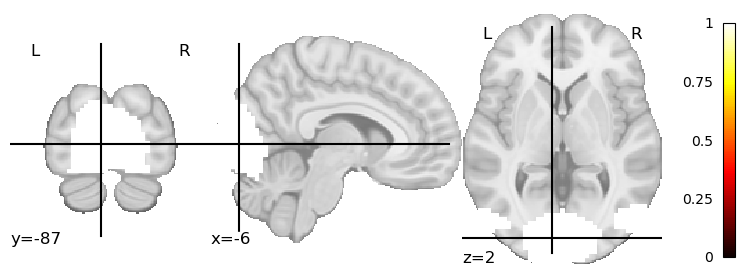

In [92]:
# aeronaut selective
rm_mask = utils.get_intersect_mask()
aero_isc_fns = glob.glob(f'{RM_RESULTS_DIR}/ISC/AERONAUT*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.mean(np.vstack([np.load(f) for f in aero_isc_fns]),axis=0)
# find the top 5 percent
q=np.percentile(data, 95)
bindata = np.where(data > q, 1, 0)
summed = np.sum(rm_mask.get_fdata())
mask = np.where(bindata >= 1, 1, 0)
print(q, np.sum(mask), np.sum(mask)/summed)
brain_mask_aero = tc.vec2vol(mask, rm_mask)
plotting.plot_stat_map(brain_mask_aero)


In [255]:
np.mean(rest_mickey), np.mean(rest_aero), np.mean(aero_mickey)

(7.270482667083473, 5.377405071886314, 1.8930775951971588)

# ROI selective analysis

In [34]:
from nilearn.image import resample_img, resample_to_img
mask1 = nib.load('./masks/RestMovie_isc_mask.nii.gz')
mask2 = nib.load('./masks/Narratives_isc_mask.nii.gz')



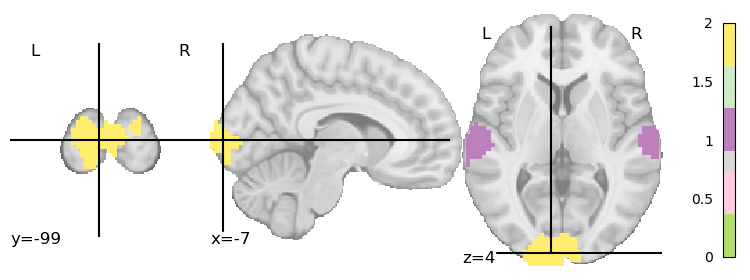

In [49]:
added = math_img('img1*2 + img2', img1=mask1, img2=resamp_mask2)
plotting.plot_stat_map(added, cmap='Set3')

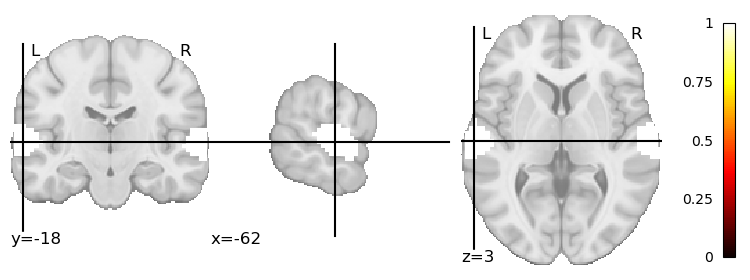

In [43]:
resamp_mask2=resample_to_img(source_img=mask2, target_img=mask1, interpolation='nearest')
plotting.plot_stat_map(resamp_mask2)

## Create ISC Masks

0.16613151746058114 (101548,) 828 0.008153779493441525


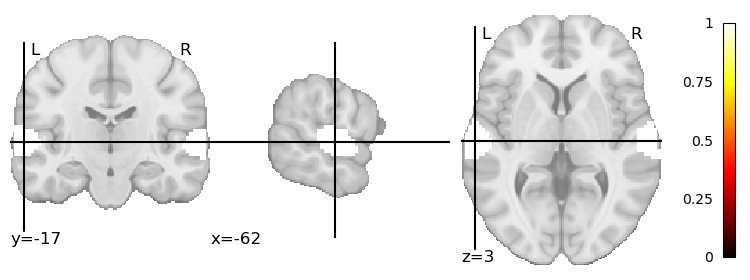

In [248]:
# determine selective voxels
narratives_mask = narutils.get_intersect_mask()
narratives_isc_fns = glob.glob(f'{NARRATIVES_RESULTS_DIR}/ISC/*ISC_all_subjects_results.npy')
# threshold at 0.1
data = np.vstack([np.load(f) for f in narratives_isc_fns])
# find the top 5 percent
q=np.percentile(data, 95)
bindata = np.where(data > q, 1, 0)
summed = np.sum(bindata, axis=0)
mask = np.where(summed >= 162, 1, 0)
print(q, summed.shape, np.sum(mask), np.sum(mask)/summed.shape[0])
brain_mask_ISC = tc.vec2vol(mask, narratives_mask)
plotting.plot_stat_map(brain_mask_ISC)
nib.save(brain_mask_ISC,'masks/Narratives_isc_mask.nii.gz')

0.3931979600750523 (70958,) 574 0.008089292257391696


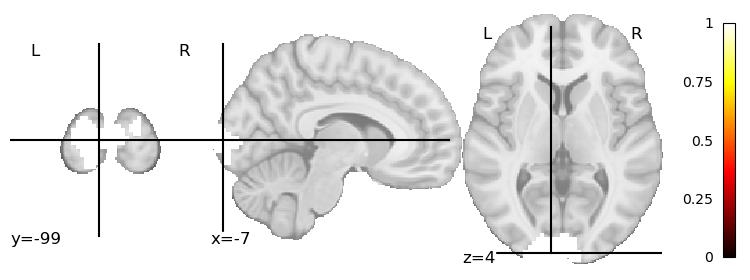

In [247]:
# determine selective voxels
rm_mask = utils.get_intersect_mask()
rm_isc_fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/ISC/*ISC_all_subjects_results.npy'))[:2] # only take movies
data = np.vstack([np.load(f) for f in rm_isc_fns])
# find the top 5 percent
q=np.percentile(data, 95)
bindata = np.where(data > q, 1, 0)
summed = np.sum(bindata, axis=0)
mask = np.where(summed >= 15, 1, 0)
print(q, summed.shape, np.sum(mask), np.sum(mask)/summed.shape[0])
brain_mask_ISC = tc.vec2vol(mask, rm_mask)
plotting.plot_stat_map(brain_mask_ISC)
nib.save(brain_mask_ISC,'masks/RestMovie_isc_mask.nii.gz')

## load in results from compare_region_ide.py


In [55]:
rm_results = pd.read_csv(f'{RM_RESULTS_DIR}/rest_movie_ISC_mask_dimensionality_results_v2.csv', index_col=0).reset_index()
nar_results = pd.read_csv(f'{NARRATIVES_RESULTS_DIR}/narratives_ISC_mask_dimensionality_results_v2.csv', index_col=0).reset_index()
rm_results['dataset'] = 'RestMovie'
nar_results['dataset'] = 'Narratives'
results=pd.concat([rm_results,nar_results])
results['is_isc'] = results.metric == 'ISC'

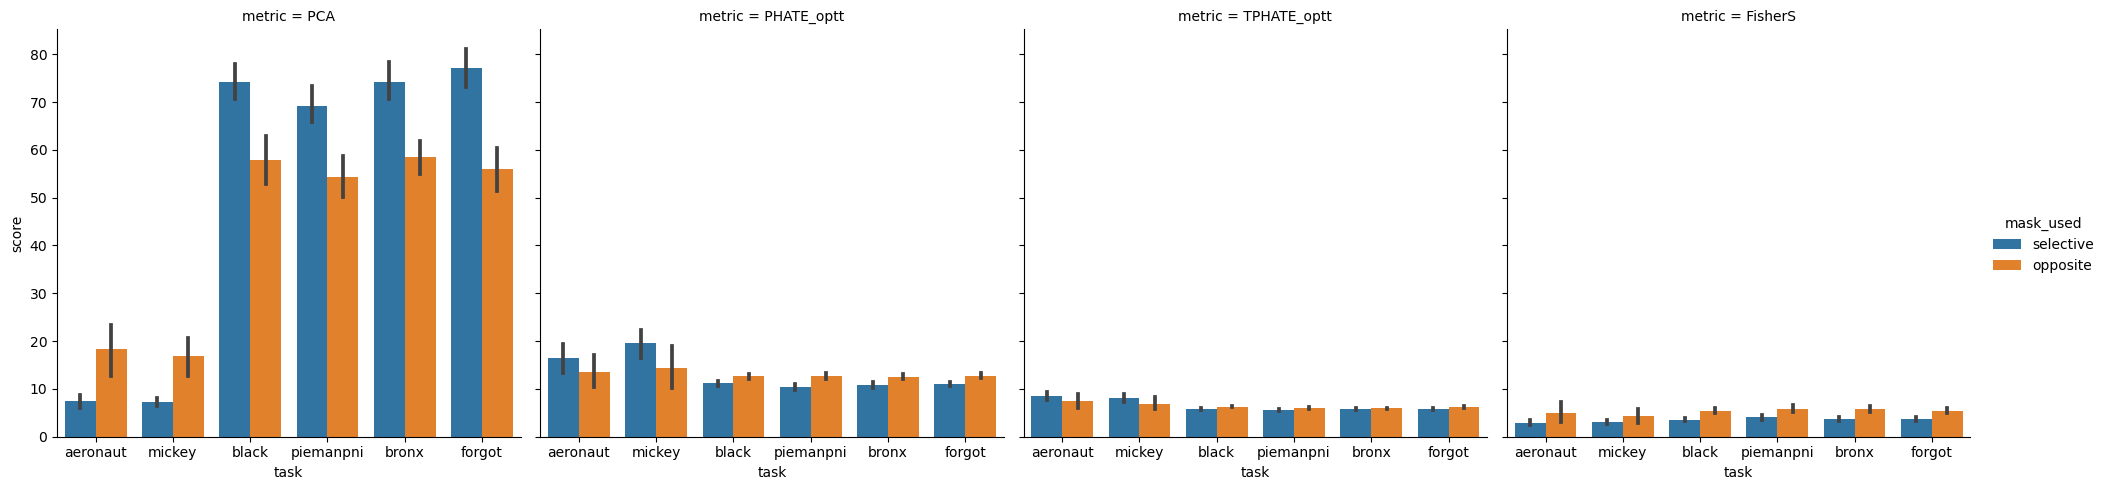

In [62]:
sns.catplot(data=results[results['is_isc']==False], col='metric', x='task', y='score',hue='mask_used', kind='bar')

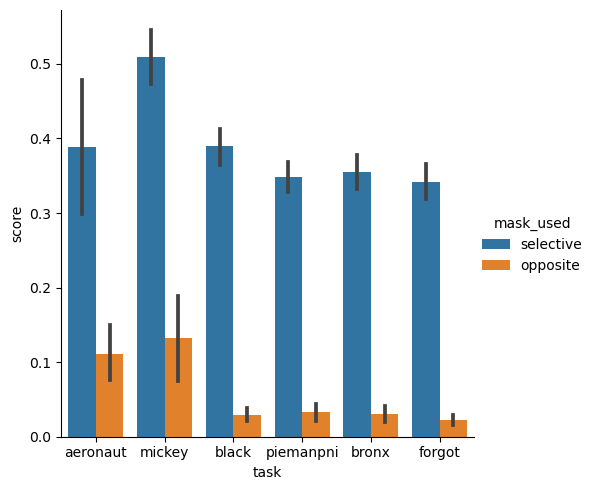

In [63]:
sns.catplot(data=results[results['is_isc']==True], x='task', y='score',hue='mask_used', kind='bar')

In [337]:
rm_results = pd.read_csv(f'{RM_RESULTS_DIR}/rest_movie_ISC_mask_dimensionality_results_v2.csv', index_col=0)
nar_results = pd.read_csv(f'{NARRATIVES_RESULTS_DIR}/narratives_ISC_mask_dimensionality_results_v2.csv', index_col=0)
rm_results['delta_DSE']=rm_results['DSE_t0']-rm_results['DSE_optt']
nar_results['delta_DSE']=nar_results['DSE_t0']-nar_results['DSE_optt']

In [338]:
res = pd.DataFrame(columns=['task','subject','metric', 'ide_same', 'ide_diff'])
for sub in rm_results.subject.unique():
    for task in rm_results.task.unique():
        for met in rm_results.metric.unique():
            subset = rm_results[(rm_results['subject']==sub) & (rm_results['task']==task) & (rm_results['metric']==met)]
            v1 = subset[subset['mask_used']=='selective']['IDE'].values[0]
            v2 = subset[subset['mask_used']=='opposite']['IDE'].values[0]
            res.loc[len(res)] = {'task':task,'subject':sub,'metric':met,'ide_same':v1, 'ide_diff':v2}


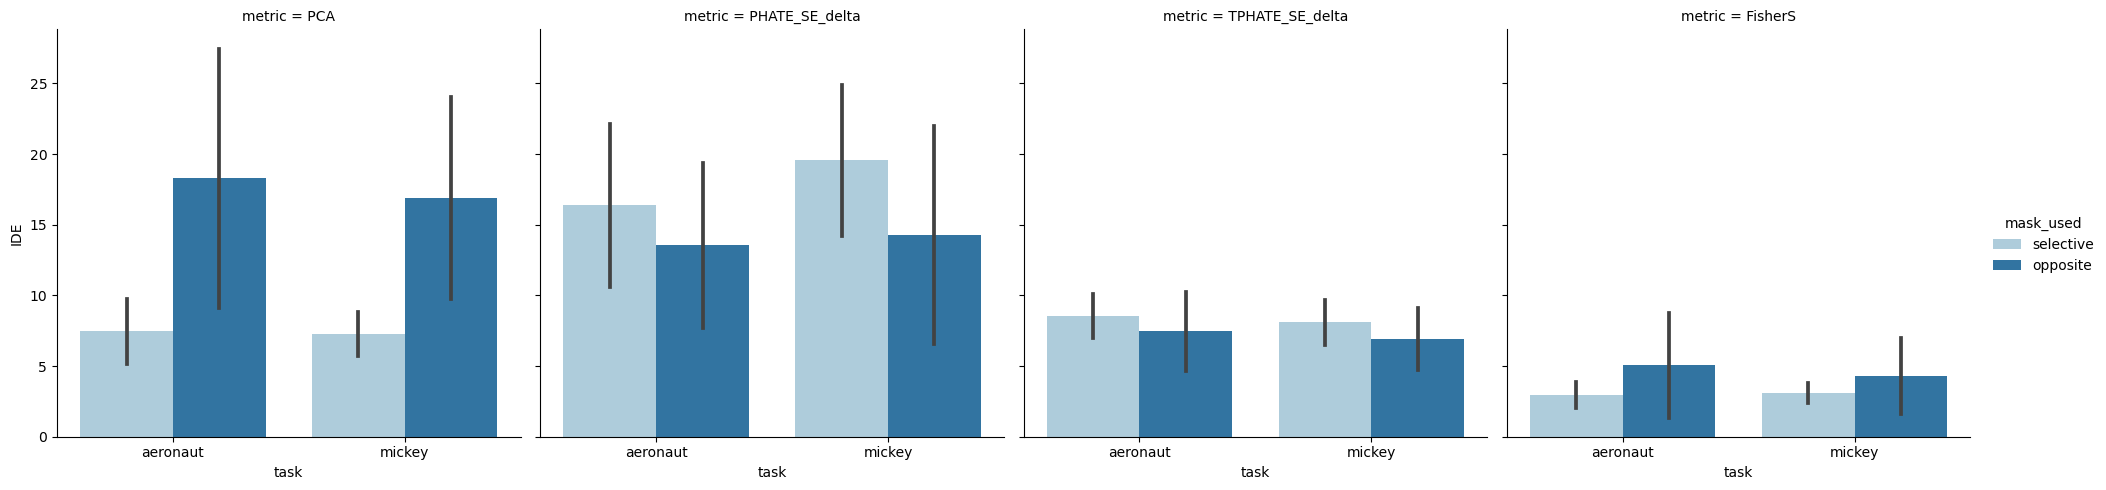

In [339]:
sns.catplot(data=rm_results, 
            col='metric', hue='mask_used', y='IDE', x='task', kind='bar', palette='Paired', ci='sd')

In [340]:
ttest_rel(res[res['metric'] == 'TPHATE_SE_delta']['ide_same'].values, 
          res[res['metric'] == 'TPHATE_SE_delta']['ide_diff'].values, alternative='greater')

Ttest_relResult(statistic=2.485250608738542, pvalue=0.010725155736970325)

In [341]:
res1 = pd.DataFrame(columns=['task','subject','metric', 'ide_same', 'ide_diff', 'delta_DSE'])
for sub in nar_results.subject.unique():
    for task in nar_results.task.unique():
        for met in nar_results.metric.unique():
            subset = nar_results[(nar_results['subject']==sub) & (nar_results['task']==task) & (nar_results['metric']==met)]
            v1 = subset[subset['mask_used']=='selective']['IDE'].values[0]
            v2 = subset[subset['mask_used']=='opposite']['IDE'].values[0]
            res1.loc[len(res1)] = {'task':task,'subject':sub,'metric':met,'ide_same':v1, 'ide_diff':v2}


In [346]:
ttest_rel(res1[res1['metric'] == 'PHATE_SE_delta']['ide_same'], 
          res1[res1['metric'] == 'PHATE_SE_delta']['ide_diff'], alternative='less')

Ttest_relResult(statistic=-9.189327213878862, pvalue=7.601725571304424e-17)

In [343]:
ttest_rel(res[res['metric'] == 'TPHATE_SE_delta']['ide_same'].values, 
          res[res['metric'] == 'TPHATE_SE_delta']['ide_diff'].values, alternative='greater')

Ttest_relResult(statistic=2.485250608738542, pvalue=0.010725155736970325)

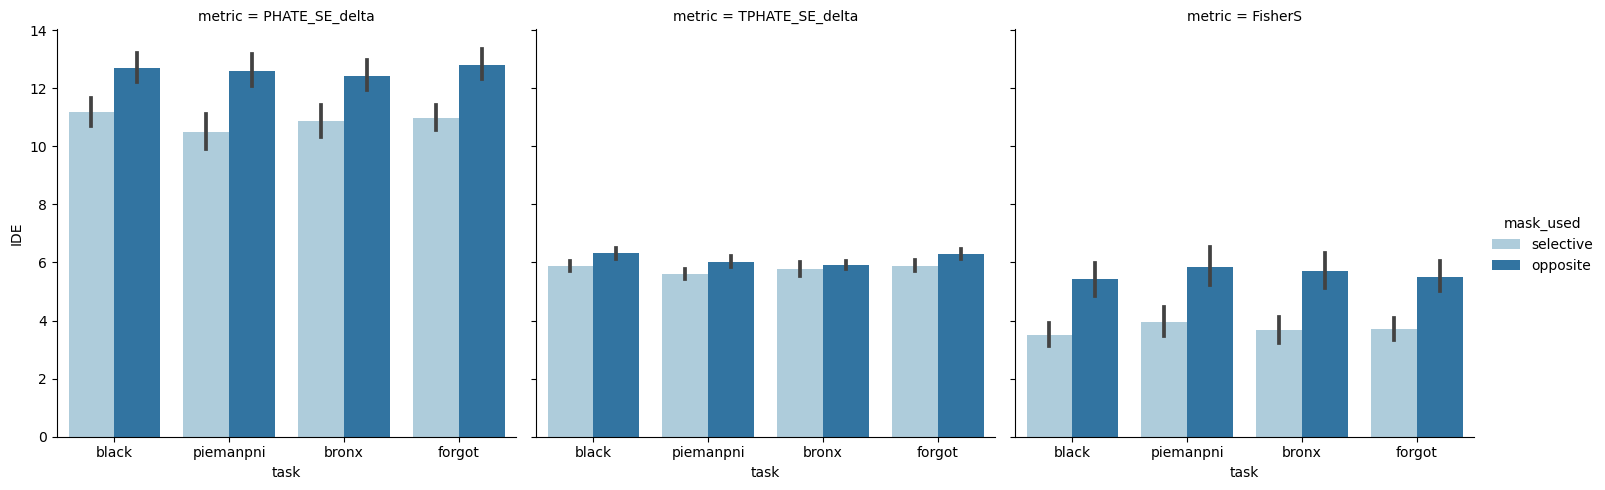

In [344]:
sns.catplot(data=nar_results[nar_results['metric']!='PCA'], 
            col='metric', hue='mask_used', y='IDE', x='task', kind='bar', palette='Paired')

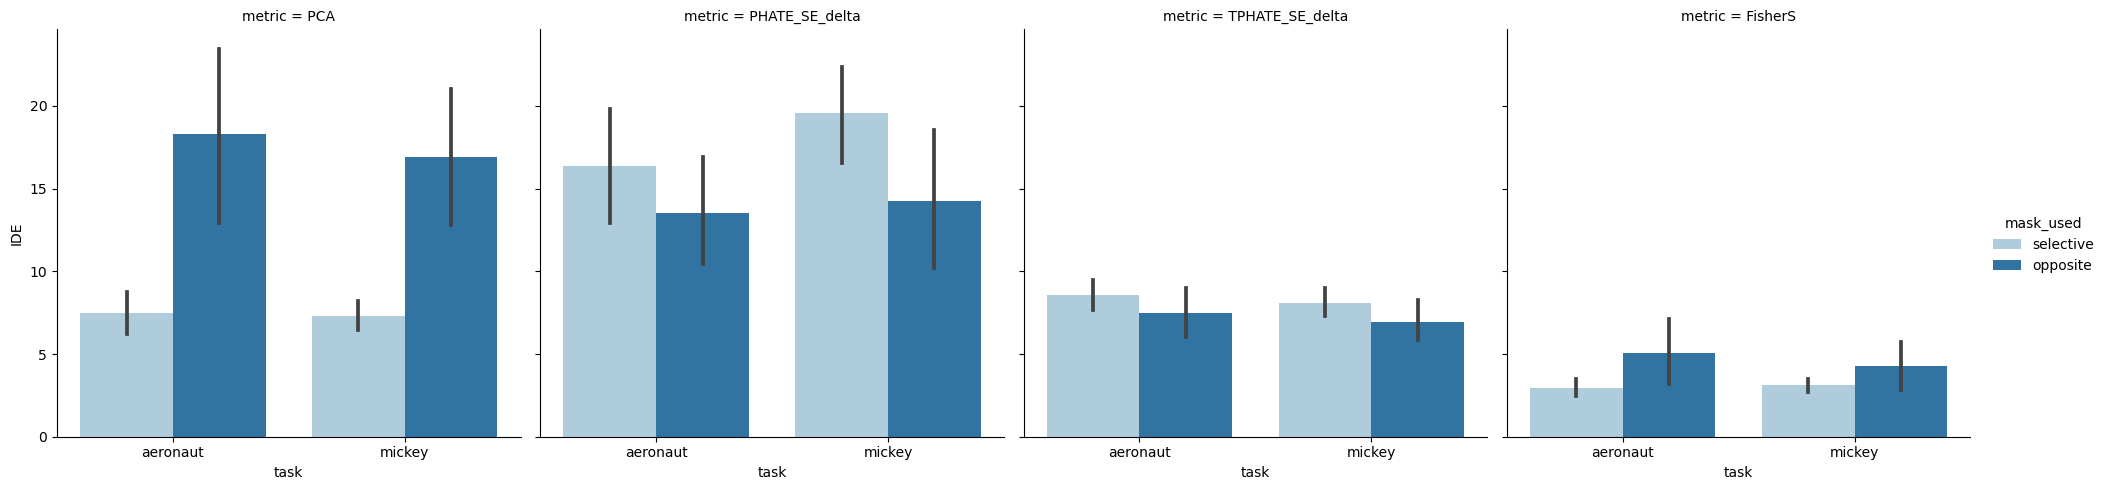

In [345]:
sns.catplot(data=rm_results, 
            col='metric', hue='mask_used', y='IDE', x='task', kind='bar', palette='Paired')

# create joblists

In [149]:
star = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_optimal_t_delta_DSE.py'
with open('joblists/rm_delta_dse_joblist.txt', 'w') as f:
    for m in ['TPHATE_SE_delta', 'PHATE_SE_delta']:
        for t in ['rest','aeronaut','mickey']:
            for i in range(11):
                f.write(f'{star} -d rest_movie -m {m} -t {t} -i {i}\n')


## Find selective regions for narratives dataset
star = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_optimal_t_delta_DSE.py'
with open('joblists/narratives_delta_dse_joblist.txt', 'w') as f:
    for m in ['TPHATE_SE_delta', 'PHATE_SE_delta']:
        for t in NARRATIVES_TIMEPOINTS.keys():
            for i in range(45):
                f.write(f'{star} -d narratives -m {m} -t {t} -i {i}\n')




In [58]:
star = 'python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/task_comparison.py'
with open('joblists/task_comparison_visualize_joblist.txt', 'w') as f:
    for d in ['rest_movie']:

        for metric in ['_PCA','DIFF_MAP_FisherS', 'PHATE_FisherS','TPHATE_FisherS','TPHATE_SE_at_t','PHATE_SE_at_t','MLE','CorrInt','MiND_ML']:
            f.write(f'{star} -d {d} -m {metric}\n')
        for k in [5,20,50]:
            for m in [1,4]:
                param = f'knn{k}_smooth_window{m}'
                f.write(f'{star} -d {d} -m tphate_optt_{param}\n')
